Load raster and verify shape of data

In [33]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Load raster
with rasterio.open("Steamboat_FirstSnow_June.tif") as src:
    first_snow = src.read(1)  # read first band
    profile = src.profile

print("Shape:", first_snow.shape)
print("Min:", np.nanmin(first_snow))
print("Max:", np.nanmax(first_snow))

Shape: (512, 512)
Min: 0
Max: 250


Visualize snow cover

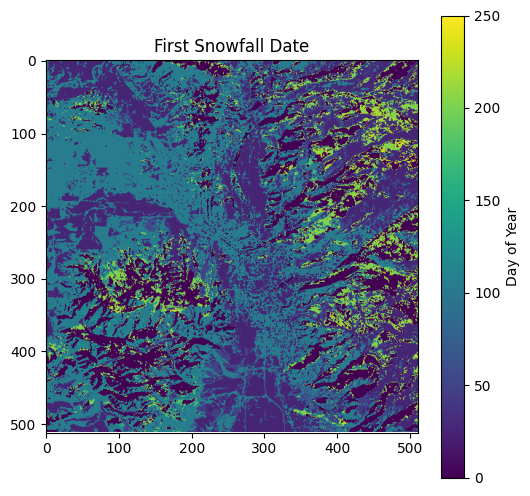

In [34]:
plt.figure(figsize=(6,6))
plt.imshow(first_snow, cmap='viridis')
plt.colorbar(label='Day of Year')
plt.title('First Snowfall Date')
plt.show()

Clean data

In [35]:
# Replace invalid values with NaN
first_snow_clean = np.where(first_snow <= 0, np.nan, first_snow)

print("Cleaned Min:", np.nanmin(first_snow_clean))
print("Cleaned Max:", np.nanmax(first_snow_clean))

Cleaned Min: 26.0
Cleaned Max: 250.0


Check distribution

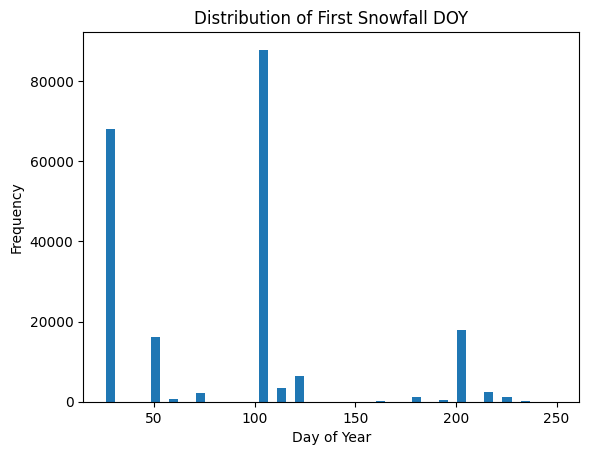

In [36]:
plt.hist(first_snow_clean[~np.isnan(first_snow_clean)], bins=50)
plt.title("Distribution of First Snowfall DOY")
plt.xlabel("Day of Year")
plt.ylabel("Frequency")
plt.show()

Covert raster to ML data

In [38]:
import numpy as np

unique_values = np.unique(first_snow_clean[~np.isnan(first_snow_clean)])
print(unique_values)
print("Number of unique first snow days:", len(unique_values))
rows, cols = first_snow_clean.shape

data = []

for i in range(rows):
    for j in range(cols):
        val = first_snow_clean[i, j]
        
        if not np.isnan(val):
            data.append([i, j, val])

import pandas as pd
df = pd.DataFrame(data, columns=["row", "col", "first_snow_doy"])

print(df.head())
print("Total samples:", len(df))

[ 26.  51.  58.  74. 106. 115. 122. 131. 163. 179. 195. 202. 218. 227.
 234. 250.]
Number of unique first snow days: 16
   row  col  first_snow_doy
0    0    0           106.0
1    0    1           106.0
2    0    2           106.0
3    0    3           106.0
4    0    4           106.0
Total samples: 208411
